# 判断为什么P=0 
 包括 冰盖、湖泊、河流、海岸线等；
 之后删除这些点

In [13]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

nc_path = Path("./data/precipitation_annual.nc")

ds = xr.open_dataset(nc_path)
da = ds["precipitation"]

# 严格用 1991–2020 这 30 年
da_30yr = da.sel(time=slice(1991, 2020))
da_mean = da_30yr.mean(dim="time", skipna=True)

print(da_mean)
print("Shape:", da_mean.shape)

<xarray.DataArray 'precipitation' (latitude: 1500, longitude: 3600)> Size: 43MB
array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * latitude   (latitude) float64 12kB 89.95 89.85 89.75 ... -59.85 -59.95
  * longitude  (longitude) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9
Shape: (1500, 3600)


In [15]:
lats = da_mean["latitude"].values
lons = da_mean["longitude"].values
mean_values = da_mean.values

lon2d, lat2d = np.meshgrid(lons, lats)

grid_df = pd.DataFrame({
    "lon": lon2d.ravel(),
    "lat": lat2d.ravel(),
    "precipitation": mean_values.ravel()
})

# 去掉 NaN
grid_df = grid_df[np.isfinite(grid_df["precipitation"])].copy()

print("Total valid grid cells:", len(grid_df))
print(grid_df.head())

Total valid grid cells: 3446983
      lon    lat  precipitation
0 -179.95  89.95            0.0
1 -179.85  89.95            0.0
2 -179.75  89.95            0.0
3 -179.65  89.95            0.0
4 -179.55  89.95            0.0


In [16]:
lats = da_mean["latitude"].values
lons = da_mean["longitude"].values
mean_values = da_mean.values

lon2d, lat2d = np.meshgrid(lons, lats)

grid_df = pd.DataFrame({
    "lon": lon2d.ravel(),
    "lat": lat2d.ravel(),
    "precipitation": mean_values.ravel()
})

# 去掉 NaN
grid_df = grid_df[np.isfinite(grid_df["precipitation"])].copy()

print("Total valid grid cells:", len(grid_df))
print(grid_df.head())

Total valid grid cells: 3446983
      lon    lat  precipitation
0 -179.95  89.95            0.0
1 -179.85  89.95            0.0
2 -179.75  89.95            0.0
3 -179.65  89.95            0.0
4 -179.55  89.95            0.0


In [17]:
grid_gdf = gpd.GeoDataFrame(
    grid_df.copy(),
    geometry=gpd.points_from_xy(grid_df["lon"], grid_df["lat"]),
    crs="EPSG:4326"
)

print(grid_gdf.shape)

(3446983, 4)


In [19]:
# 1. 陆地 polygons
land_path = Path("./data/water_area/ne_10m_land/ne_10m_land.shp")
land = gpd.read_file(land_path)

# 2. 湖泊 polygons
lakes_path = Path("./data/water_area/ne_10m_lakes/ne_10m_lakes.shp")
lakes = gpd.read_file(lakes_path)

# 3. 冰盖 polygons
glacier_path = Path("./data/water_area/ne_10m_glaciated_areas/ne_10m_glaciated_areas.shp")
glaciers = gpd.read_file(glacier_path)

# 统一坐标系
if land.crs is not None:
    land = land.to_crs(epsg=4326)

if lakes.crs is not None:
    lakes = lakes.to_crs(epsg=4326)

if glaciers.crs is not None:
    glaciers = glaciers.to_crs(epsg=4326)

print("Land polygons:", len(land))
print("Lake polygons:", len(lakes))
print("Glacier polygons:", len(glaciers))

Land polygons: 11
Lake polygons: 1355
Glacier polygons: 1886


In [20]:
def mark_points_in_polygons(points_gdf, polygons_gdf, predicate="intersects"):
    joined = gpd.sjoin(
        points_gdf[["geometry"]],
        polygons_gdf,
        how="left",
        predicate=predicate
    )
    matched_idx = joined.loc[joined["index_right"].notna()].index.unique()
    return points_gdf.index.isin(matched_idx)

In [21]:
result = grid_gdf.copy()

result["on_land"] = mark_points_in_polygons(result, land, predicate="intersects")
result["in_ocean"] = ~result["on_land"]

print("Land cells:", result["on_land"].sum())
print("Ocean cells:", result["in_ocean"].sum())

Land cells: 1536665
Ocean cells: 1910318


In [22]:
result["p_zero"] = (result["precipitation"] == 0)

print("P = 0 cells:", result["p_zero"].sum())

P = 0 cells: 2000396


In [23]:
p0_points = result[result["p_zero"]].copy()

p0_points["in_lake"] = mark_points_in_polygons(p0_points, lakes, predicate="intersects")
p0_points["in_glacier"] = mark_points_in_polygons(p0_points, glaciers, predicate="intersects")

p0_points["category"] = "neither"
p0_points.loc[p0_points["in_lake"] & ~p0_points["in_glacier"], "category"] = "lake_only"
p0_points.loc[~p0_points["in_lake"] & p0_points["in_glacier"], "category"] = "glacier_only"
p0_points.loc[p0_points["in_lake"] & p0_points["in_glacier"], "category"] = "both"

print("P=0 points:", len(p0_points))
print(p0_points["category"].value_counts())

P=0 points: 2000396
category
neither         1924317
glacier_only      64206
lake_only         11873
Name: count, dtype: int64


In [24]:
total_cells = len(result)

ocean_cells = result["in_ocean"].sum()
land_cells = result["on_land"].sum()
p0_cells = result["p_zero"].sum()

lake_only = (p0_points["category"] == "lake_only").sum()
glacier_only = (p0_points["category"] == "glacier_only").sum()
both = (p0_points["category"] == "both").sum()
neither = (p0_points["category"] == "neither").sum()

print("Relative to all valid grid cells")
print("-" * 60)
print(f"Total valid cells: {total_cells:,}")
print(f"Ocean cells:       {ocean_cells:,} ({ocean_cells / total_cells * 100:.2f}%)")
print(f"Land cells:        {land_cells:,} ({land_cells / total_cells * 100:.2f}%)")
print(f"P = 0 cells:       {p0_cells:,} ({p0_cells / total_cells * 100:.2f}%)")
print(f"  lake_only:       {lake_only:,} ({lake_only / total_cells * 100:.2f}%)")
print(f"  glacier_only:    {glacier_only:,} ({glacier_only / total_cells * 100:.2f}%)")
print(f"  both:            {both:,} ({both / total_cells * 100:.2f}%)")
print(f"  neither:         {neither:,} ({neither / total_cells * 100:.2f}%)")

Relative to all valid grid cells
------------------------------------------------------------
Total valid cells: 3,446,983
Ocean cells:       1,910,318 (55.42%)
Land cells:        1,536,665 (44.58%)
P = 0 cells:       2,000,396 (58.03%)
  lake_only:       11,873 (0.34%)
  glacier_only:    64,206 (1.86%)
  both:            0 (0.00%)
  neither:         1,924,317 (55.83%)


## 5.2 相对于 P = 0 的格点

In [25]:
total_p0 = len(p0_points)

print("\nRelative to P = 0 cells only")
print("-" * 60)
print(f"Total P = 0 cells: {total_p0:,}")
print(f"  lake_only:       {lake_only:,} ({lake_only / total_p0 * 100:.2f}%)")
print(f"  glacier_only:    {glacier_only:,} ({glacier_only / total_p0 * 100:.2f}%)")
print(f"  both:            {both:,} ({both / total_p0 * 100:.2f}%)")
print(f"  neither:         {neither:,} ({neither / total_p0 * 100:.2f}%)")


Relative to P = 0 cells only
------------------------------------------------------------
Total P = 0 cells: 2,000,396
  lake_only:       11,873 (0.59%)
  glacier_only:    64,206 (3.21%)
  both:            0 (0.00%)
  neither:         1,924,317 (96.20%)


## 5.3 只看陆地上的 P = 0


In [26]:
p0_land = p0_points[p0_points["on_land"]].copy()

lake_only_land = (p0_land["category"] == "lake_only").sum()
glacier_only_land = (p0_land["category"] == "glacier_only").sum()
both_land = (p0_land["category"] == "both").sum()
neither_land = (p0_land["category"] == "neither").sum()

total_p0_land = len(p0_land)

print("\nRelative to land P = 0 cells only")
print("-" * 60)
print(f"Total land P = 0 cells: {total_p0_land:,}")
print(f"  lake_only:            {lake_only_land:,} ({lake_only_land / total_p0_land * 100:.2f}%)")
print(f"  glacier_only:         {glacier_only_land:,} ({glacier_only_land / total_p0_land * 100:.2f}%)")
print(f"  both:                 {both_land:,} ({both_land / total_p0_land * 100:.2f}%)")
print(f"  neither:              {neither_land:,} ({neither_land / total_p0_land * 100:.2f}%)")


Relative to land P = 0 cells only
------------------------------------------------------------
Total land P = 0 cells: 94,978
  lake_only:            11,873 (12.50%)
  glacier_only:         64,206 (67.60%)
  both:                 0 (0.00%)
  neither:              18,899 (19.90%)


In [27]:
summary = pd.DataFrame({
    "metric": [
        "total_valid_cells",
        "ocean_cells",
        "land_cells",
        "p0_cells",
        "p0_lake_only",
        "p0_glacier_only",
        "p0_both",
        "p0_neither",
        "land_p0_cells",
        "land_p0_lake_only",
        "land_p0_glacier_only",
        "land_p0_both",
        "land_p0_neither",
    ],
    "count": [
        total_cells,
        ocean_cells,
        land_cells,
        p0_cells,
        lake_only,
        glacier_only,
        both,
        neither,
        total_p0_land,
        lake_only_land,
        glacier_only_land,
        both_land,
        neither_land,
    ]
})

summary["pct_of_all_valid_cells"] = summary["count"] / total_cells * 100
summary

,metric,count,pct_of_all_valid_cells
0,total_valid_cells,3446983,100.000000
1,ocean_cells,1910318,55.420001
2,land_cells,1536665,44.579999
3,p0_cells,2000396,58.033242
4,p0_lake_only,11873,0.344446
5,p0_glacier_only,64206,1.862672
6,p0_both,0,0.000000
7,p0_neither,1924317,55.826124
8,land_p0_cells,94978,2.755395
9,land_p0_lake_only,11873,0.344446


## 把剩下的点画一下，是什么点

In [28]:
land_p0_neither = p0_points[
    (p0_points["on_land"]) &
    (p0_points["category"] == "neither")
].copy()

print("Number of unexplained land P=0 cells:", len(land_p0_neither))
print(land_p0_neither.head())

Number of unexplained land P=0 cells: 18899
          lon    lat  precipitation              geometry  on_land  in_ocean  \
231853 -34.65  83.55            0.0  POINT (-34.65 83.55)     True     False   
231902 -29.75  83.55            0.0  POINT (-29.75 83.55)     True     False   
231903 -29.65  83.55            0.0  POINT (-29.65 83.55)     True     False   
235420 -37.95  83.45            0.0  POINT (-37.95 83.45)     True     False   
235421 -37.85  83.45            0.0  POINT (-37.85 83.45)     True     False   

        p_zero  in_lake  in_glacier category  
231853    True    False       False  neither  
231902    True    False       False  neither  
231903    True    False       False  neither  
235420    True    False       False  neither  
235421    True    False       False  neither  


In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_land_p0_neither_global(df, point_color="#D95F5F", point_size=6, alpha=0.75):
    fig = plt.figure(figsize=(12, 6), dpi=180)
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()

    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
    ax.coastlines(linewidth=0.4, color="black", zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=1)

    ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.3,
        color="0.75",
        alpha=0.6,
        linestyle="-",
        zorder=1
    )

    ax.scatter(
        df["lon"],
        df["lat"],
        s=point_size,
        color=point_color,
        alpha=alpha,
        linewidth=0,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    ax.set_title("Land cells with P = 0 that are neither lakes nor glaciers", fontsize=12, pad=8)
    plt.show()

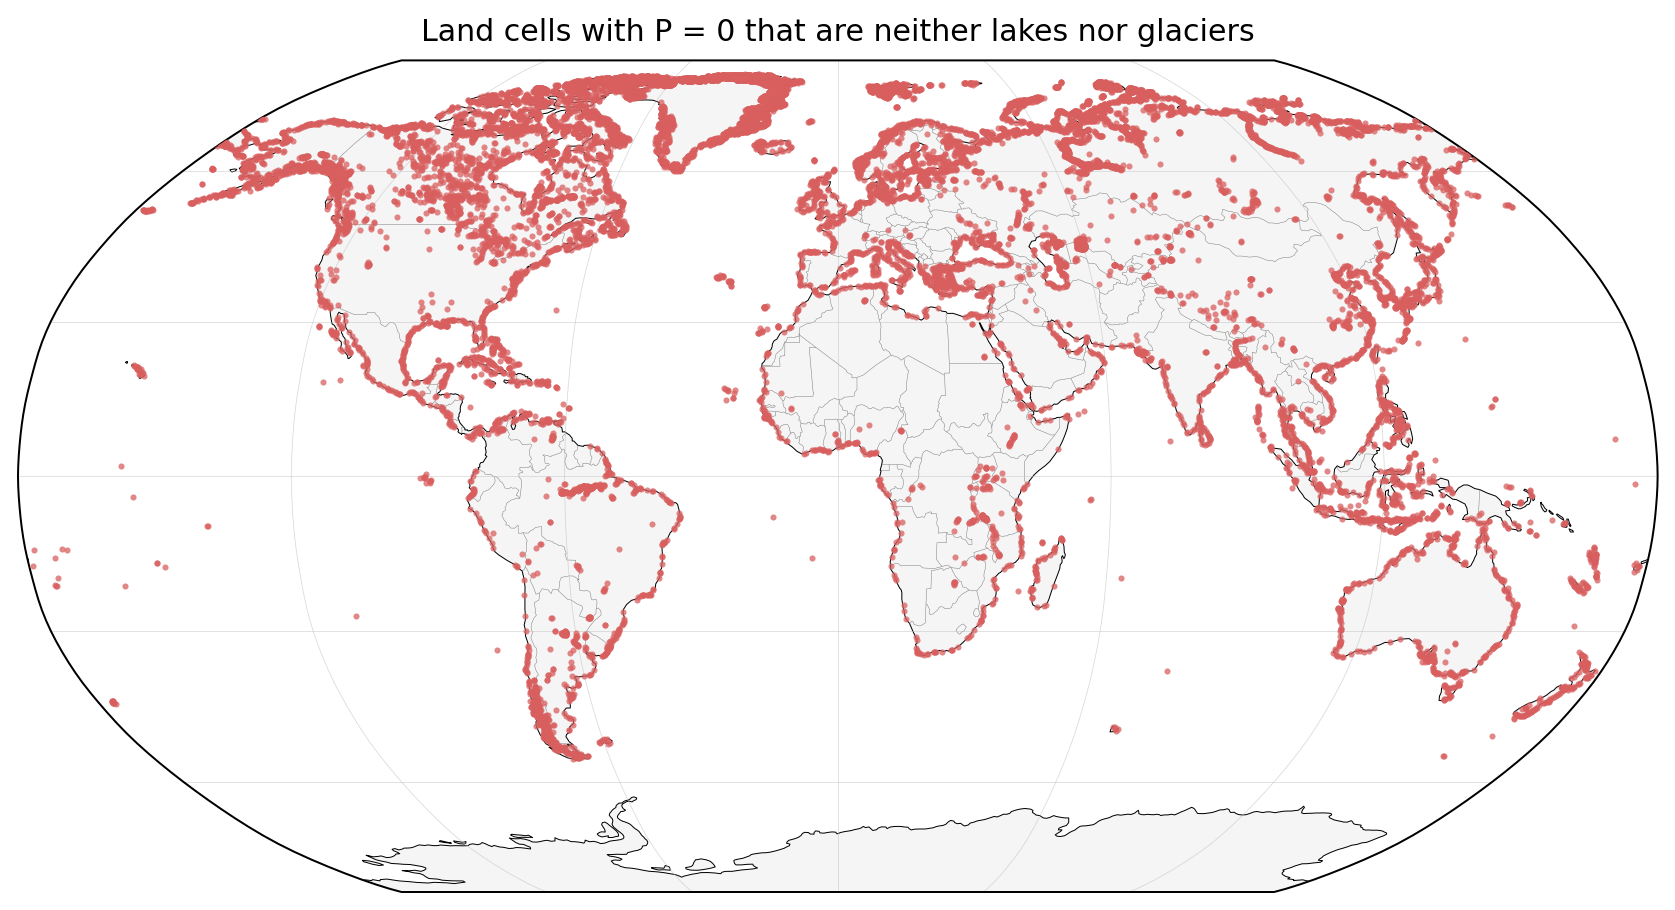

In [30]:
plot_land_p0_neither_global(land_p0_neither)

In [31]:
from shapely.ops import unary_union

# 合并所有陆地 polygon
land_union = unary_union(land.geometry)

# 取陆地外边界，作为海岸线
coastline = land_union.boundary

print(type(coastline))

<class 'shapely.geometry.multilinestring.MultiLineString'>


In [32]:
import geopandas as gpd

# 点转成 GeoDataFrame
land_p0_neither_gdf = gpd.GeoDataFrame(
    land_p0_neither.copy(),
    geometry=land_p0_neither.geometry,
    crs="EPSG:4326"
)

# 海岸线转成 GeoDataFrame
coastline_gdf = gpd.GeoDataFrame(
    {"name": ["coastline"]},
    geometry=[coastline],
    crs="EPSG:4326"
)

# 投影到米单位坐标系
land_p0_neither_m = land_p0_neither_gdf.to_crs(epsg=3857)
coastline_m = coastline_gdf.to_crs(epsg=3857)

print(land_p0_neither_m.shape)
print(coastline_m.shape)

(18899, 10)
(1, 2)


In [33]:
# 取海岸线几何
coast_geom = coastline_m.geometry.iloc[0]

# 计算每个点到海岸线的最短距离，单位米
land_p0_neither_m["dist_to_coast_m"] = land_p0_neither_m.geometry.distance(coast_geom)

# 转成公里，方便看
land_p0_neither_m["dist_to_coast_km"] = land_p0_neither_m["dist_to_coast_m"] / 1000

print(land_p0_neither_m[["lon", "lat", "dist_to_coast_km"]].head())
print(land_p0_neither_m["dist_to_coast_km"].describe())

          lon    lat  dist_to_coast_km
231853 -34.65  83.55          9.641892
231902 -29.75  83.55          6.931090
231903 -29.65  83.55          2.469528
235420 -37.95  83.45          0.995646
235421 -37.85  83.45          8.979342
count    18899.000000
mean       192.675740
std        418.437941
min          0.000163
25%          1.450509
50%          8.947930
75%        147.088811
max       3607.992826
Name: dist_to_coast_km, dtype: float64


In [34]:
def summarize_coastal_proximity(df, thresholds_km=(5, 10, 20, 50, 100)):
    total = len(df)
    print(f"Total unexplained land P=0 cells: {total:,}\n")

    for th in thresholds_km:
        n = (df["dist_to_coast_km"] <= th).sum()
        pct = n / total * 100 if total > 0 else 0
        print(f"Within {th:>3} km of coastline: {n:,} ({pct:.2f}%)")

summarize_coastal_proximity(land_p0_neither_m)

Total unexplained land P=0 cells: 18,899

Within   5 km of coastline: 8,425 (44.58%)
Within  10 km of coastline: 9,587 (50.73%)
Within  20 km of coastline: 10,387 (54.96%)
Within  50 km of coastline: 11,772 (62.29%)
Within 100 km of coastline: 13,244 (70.08%)


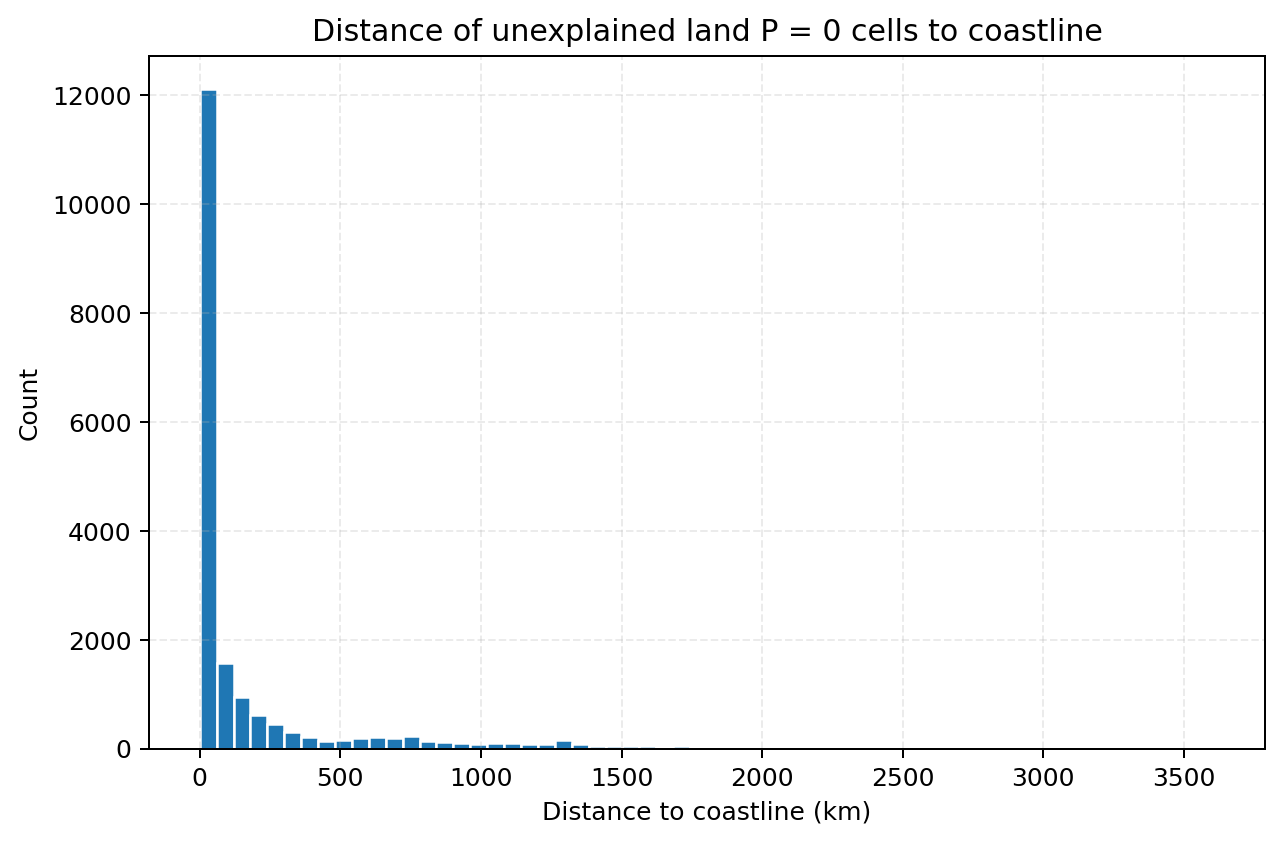

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5), dpi=180)
plt.hist(land_p0_neither_m["dist_to_coast_km"], bins=60, edgecolor="white")
plt.xlabel("Distance to coastline (km)")
plt.ylabel("Count")
plt.title("Distance of unexplained land P = 0 cells to coastline")
plt.grid(True, alpha=0.25, linestyle="--")
plt.show()

In [36]:
coastal_50km = land_p0_neither_m[land_p0_neither_m["dist_to_coast_km"] <= 50].to_crs(epsg=4326)

print("Points within 50 km of coastline:", len(coastal_50km))

Points within 50 km of coastline: 11772


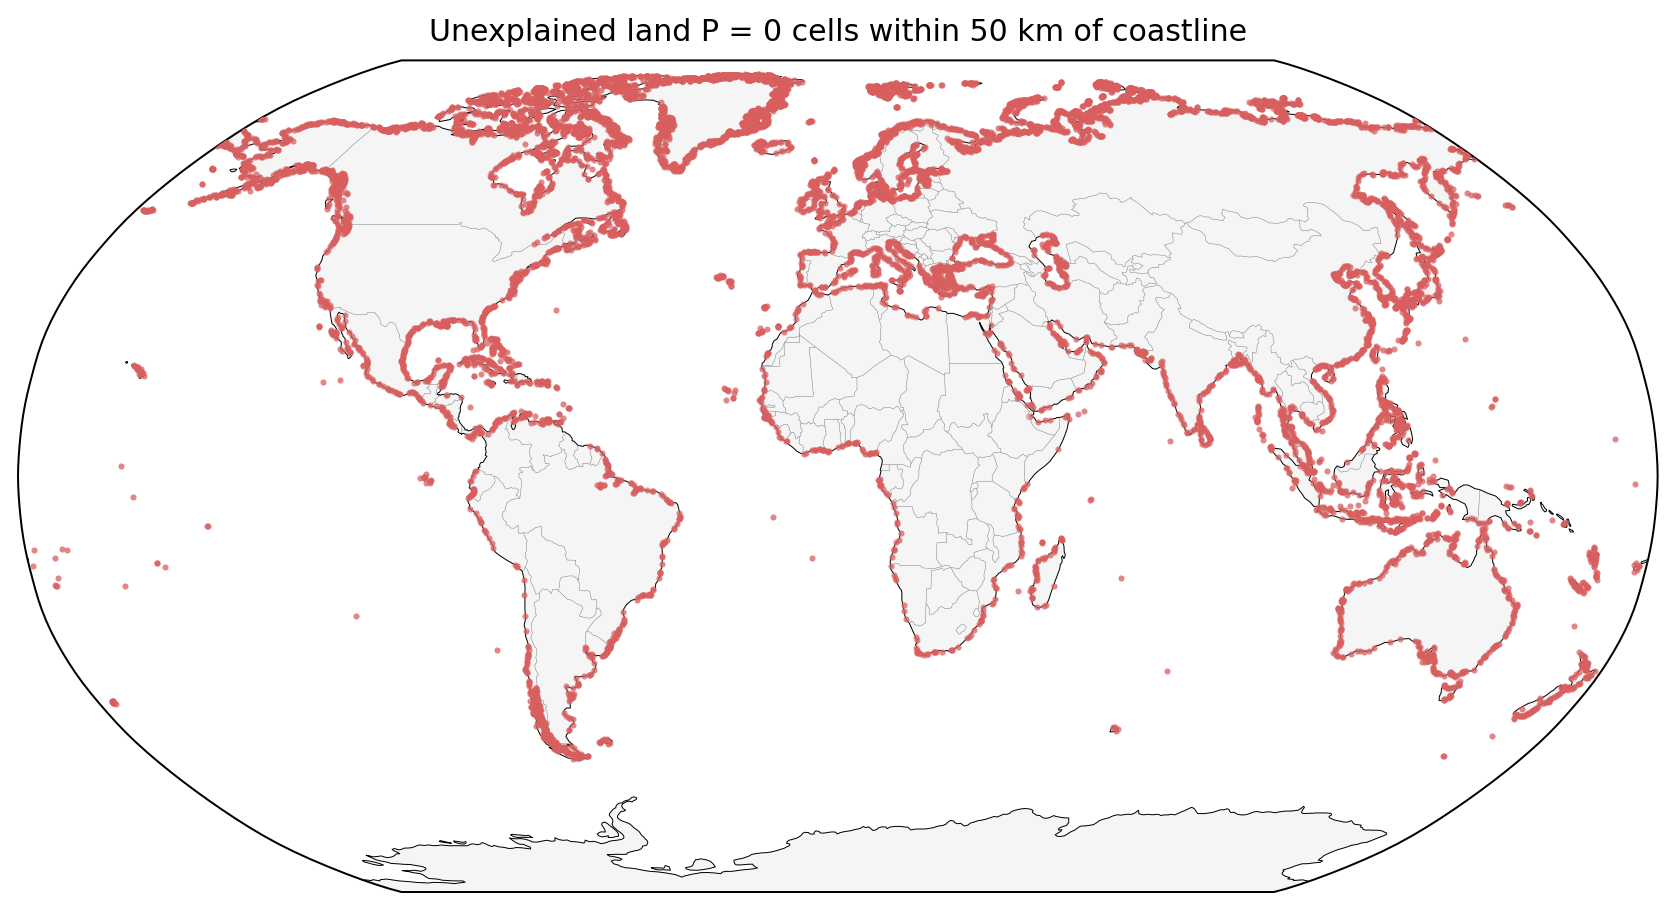

In [37]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 6), dpi=180)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=1)

ax.scatter(
    coastal_50km["lon"],
    coastal_50km["lat"],
    s=6,
    color="#D95F5F",
    alpha=0.75,
    linewidth=0,
    transform=ccrs.PlateCarree(),
    zorder=3
)

ax.set_title("Unexplained land P = 0 cells within 50 km of coastline", fontsize=12, pad=8)
plt.show()

In [65]:
coastal_threshold_km = 150

coastal_neither = (land_p0_neither_m["dist_to_coast_km"] <= coastal_threshold_km).sum()
inland_residual = (land_p0_neither_m["dist_to_coast_km"] > coastal_threshold_km).sum()

print("coastal_neither:", coastal_neither)
print("inland_residual:", inland_residual)

coastal_neither: 14210
inland_residual: 4689


In [66]:
land_p0_summary = pd.DataFrame({
    "category": [
        "Total land P=0 cells",
        "Explained by glaciers",
        "Explained by lakes",
        f"Likely coastal-edge artifacts (<= {coastal_threshold_km} km from coastline)",
        f"Unexplained inland residuals (> {coastal_threshold_km} km from coastline)",
        "Explained by both lake and glacier"
    ],
    "count": [
        total_p0_land,
        glacier_only_land,
        lake_only_land,
        coastal_neither,
        inland_residual,
        both_land
    ]
})

land_p0_summary["percentage (%)"] = land_p0_summary["count"] / total_p0_land * 100
land_p0_summary

,category,count,percentage (%)
0,Total land P=0 cells,94978,100.000000
1,Explained by glaciers,64206,67.600918
2,Explained by lakes,11873,12.500790
3,Likely coastal-edge artifacts (<= 150 km from ...,14210,14.961359
4,Unexplained inland residuals (> 150 km from co...,4689,4.936933
5,Explained by both lake and glacier,0,0.000000


In [45]:
# land_p0_summary = pd.DataFrame({
#     "metric": [
#         "total_land_p0_cells",
#         "glacier_only",
#         "lake_only",
#         f"coastal_neither_le_{coastal_threshold_km}km",
#         f"inland_residual_gt_{coastal_threshold_km}km",
#         "both_lake_and_glacier"
#     ],
#     "count": [
#         total_p0_land,
#         glacier_only_land,
#         lake_only_land,
#         coastal_neither,
#         inland_residual,
#         both_land
#     ]
# })

# land_p0_summary["pct_of_land_p0_cells"] = land_p0_summary["count"] / total_p0_land * 100
# land_p0_summary

,metric,count,pct_of_land_p0_cells
0,total_land_p0_cells,94978,100.000000
1,glacier_only,64206,67.600918
2,lake_only,11873,12.500790
3,coastal_neither_le_50km,11772,12.394449
4,inland_residual_gt_50km,7127,7.503843
5,both_lake_and_glacier,0,0.000000


In [60]:
import numpy as np
import pandas as pd

# 你可以改这个阈值
coastal_threshold_km = 100

# 1. 海洋上的 P=0
ocean_p0_cells = ((result["in_ocean"]) & (result["p_zero"])).sum()

# 2. 陆地上的 P=0
land_p0_cells = total_p0_land   # 你前面已经算过

# 3. 陆地 P=0 中，湖泊 / 冰盖 / 海岸线 / 剩余内陆
coastal_p0_land = (land_p0_neither_m["dist_to_coast_km"] <= coastal_threshold_km).sum()
inland_other_p0_land = (land_p0_neither_m["dist_to_coast_km"] > coastal_threshold_km).sum()

final_summary = pd.DataFrame({
    "metric": [
        "total_valid_cells",
        "ocean_p0_cells",
        "land_p0_cells",
        "land_p0_glacier",
        "land_p0_lake",
        f"land_p0_coastal_le_{coastal_threshold_km}km",
        f"land_p0_other_inland_gt_{coastal_threshold_km}km",
    ],
    "count": [
        total_cells,
        ocean_p0_cells,
        land_p0_cells,
        glacier_only_land,
        lake_only_land,
        coastal_p0_land,
        inland_other_p0_land,
    ]
})

# 相对于全部有效格点的占比
final_summary["pct_of_all_valid_cells"] = final_summary["count"] / total_cells * 100

# 相对于陆地 P=0 的占比
final_summary["pct_of_land_p0_cells"] = np.nan
mask = final_summary["metric"].isin([
    "land_p0_glacier",
    "land_p0_lake",
    f"land_p0_coastal_le_{coastal_threshold_km}km",
    f"land_p0_other_inland_gt_{coastal_threshold_km}km",
])
final_summary.loc[mask, "pct_of_land_p0_cells"] = (
    final_summary.loc[mask, "count"] / land_p0_cells * 100
)

final_summary

,metric,count,pct_of_all_valid_cells,pct_of_land_p0_cells
0,total_valid_cells,3446983,100.000000,NaN
1,ocean_p0_cells,1905418,55.277847,NaN
2,land_p0_cells,94978,2.755395,NaN
3,land_p0_glacier,64206,1.862672,67.600918
4,land_p0_lake,11873,0.344446,12.500790
5,land_p0_coastal_le_100km,13244,0.384220,13.944282
6,land_p0_other_inland_gt_100km,5655,0.164057,5.954010


In [61]:
# 剩下的点：陆地 P=0，且不在 lake / glacier，且距离海岸线 > 50 km
coastal_threshold_km = 200

remaining_p0_land = land_p0_neither_m[
    land_p0_neither_m["dist_to_coast_km"] > coastal_threshold_km
].copy()

# 转回经纬度坐标，方便画图
remaining_p0_land_ll = remaining_p0_land.to_crs(epsg=4326)

print("Remaining unexplained inland land P=0 cells:", len(remaining_p0_land_ll))
print(remaining_p0_land_ll[["lon", "lat", "dist_to_coast_km"]].head())

Remaining unexplained inland land P=0 cells: 4036
          lon    lat  dist_to_coast_km
257108 -29.15  82.85        209.753370
257109 -29.05  82.85        204.381049
260694 -30.55  82.75        204.374730
260697 -30.25  82.75        226.227822
260698 -30.15  82.75        234.064504


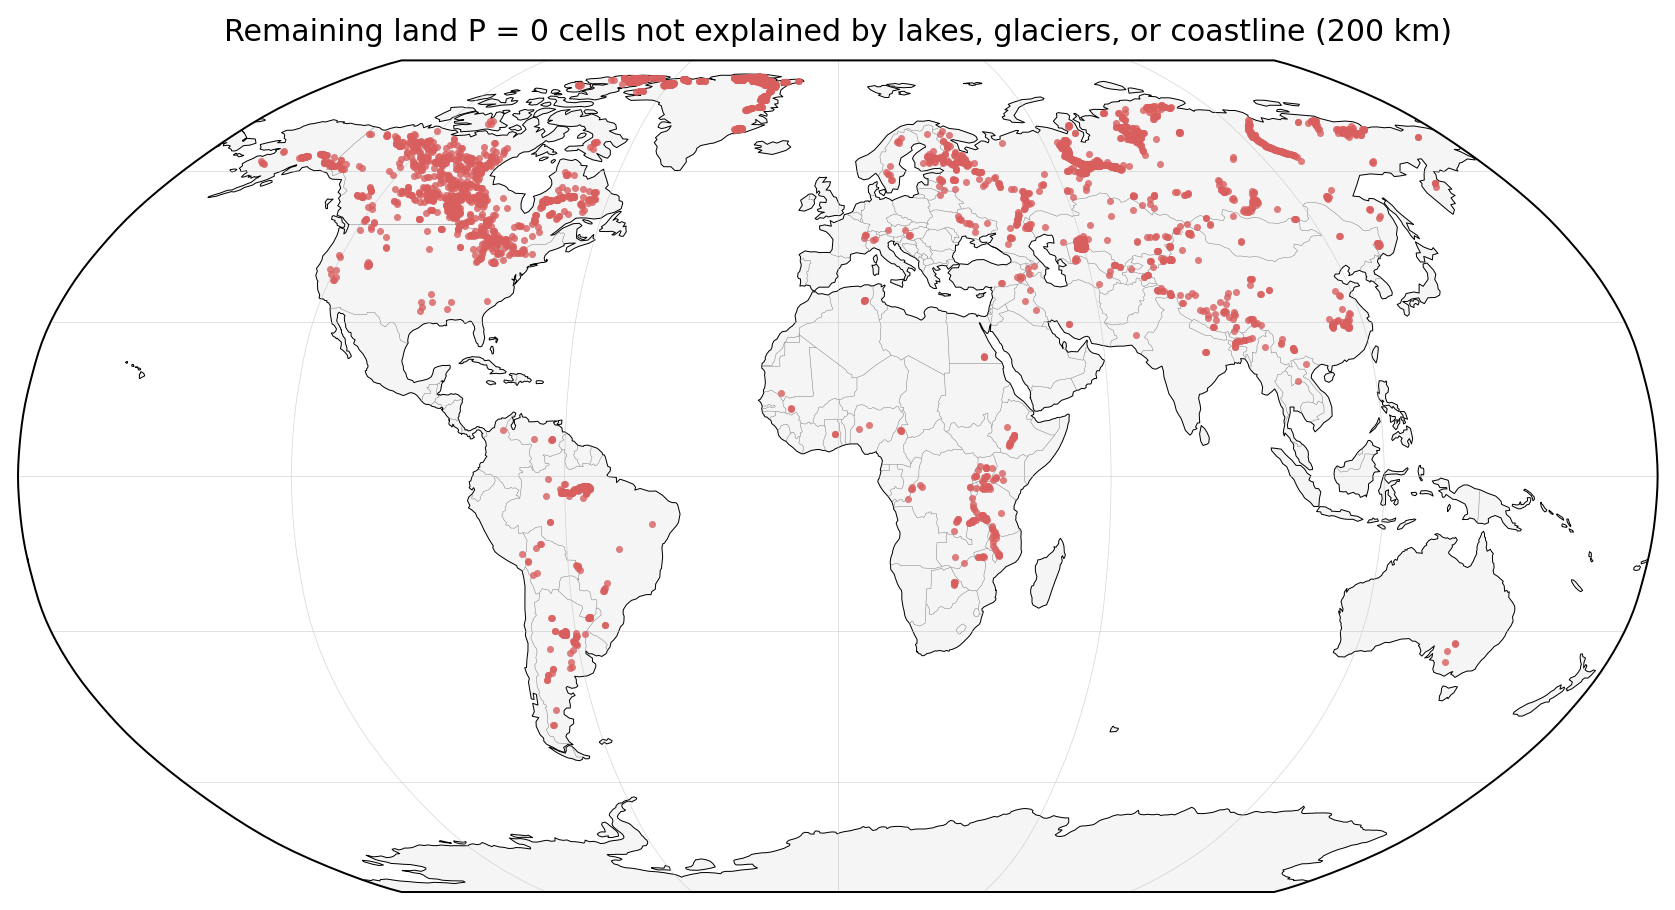

In [62]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 6), dpi=180)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=1)

ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.3,
    color="0.75",
    alpha=0.6,
    linestyle="-",
    zorder=1
)

ax.scatter(
    remaining_p0_land_ll["lon"],
    remaining_p0_land_ll["lat"],
    s=8,
    color="#D95F5F",
    alpha=0.8,
    linewidth=0,
    transform=ccrs.PlateCarree(),
    zorder=3
)

ax.set_title(
    f"Remaining land P = 0 cells not explained by lakes, glaciers, or coastline ({coastal_threshold_km} km)",
    fontsize=12,
    pad=8
)
plt.show()

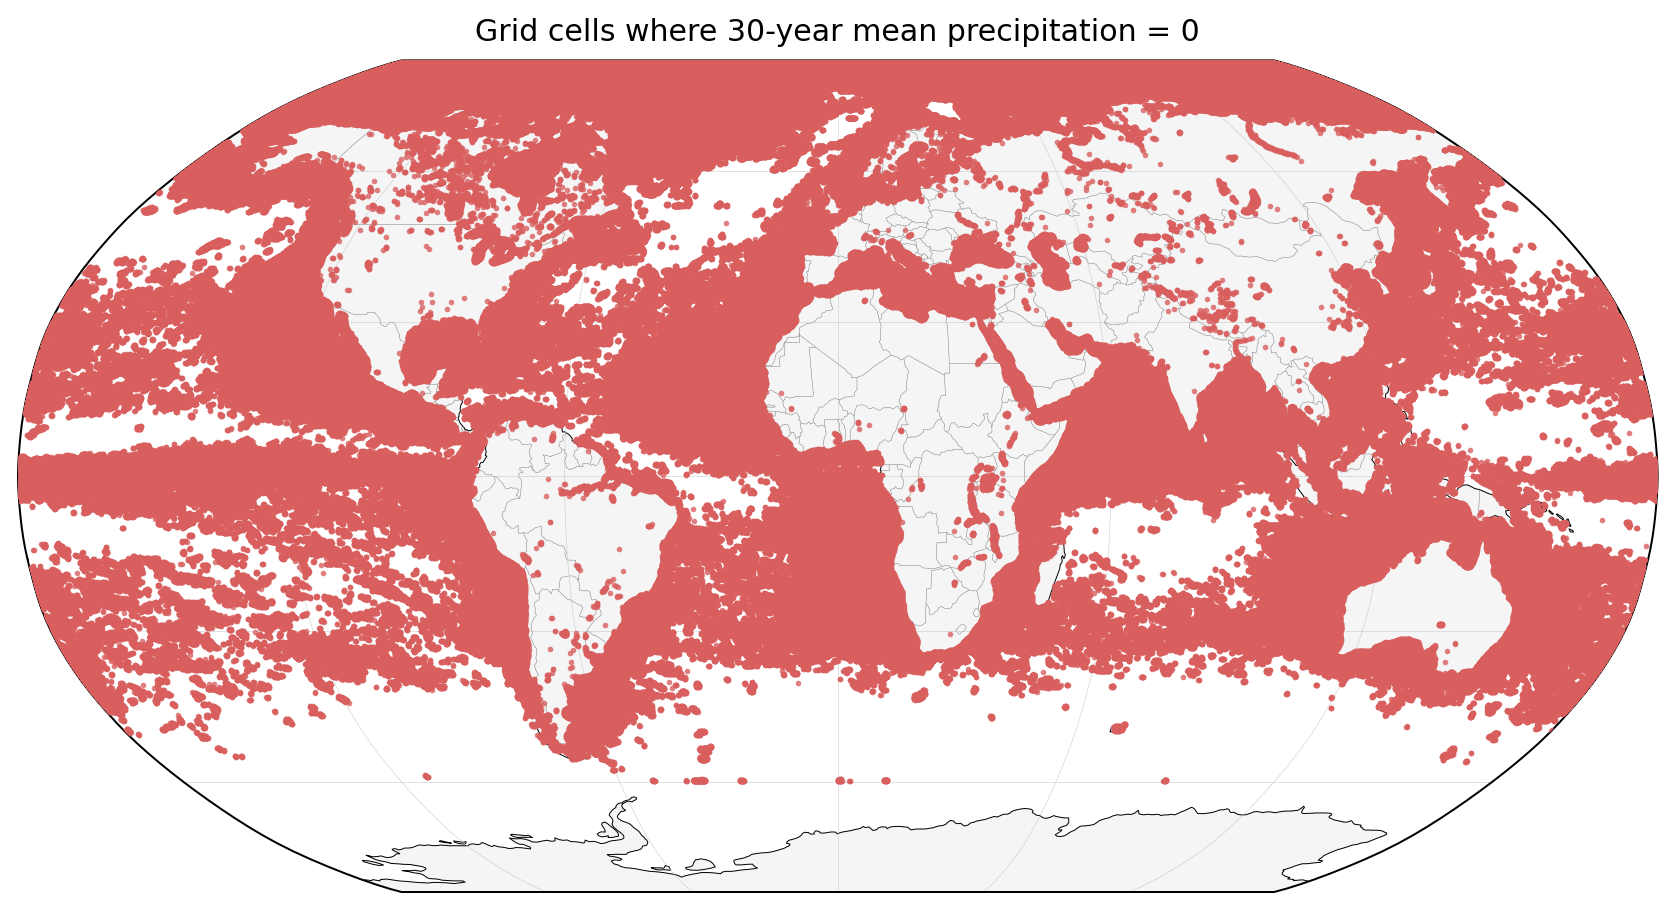

In [11]:
fig = plt.figure(figsize=(12, 6), dpi=180)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=2)

ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.3,
    color="0.75",
    alpha=0.6,
    linestyle="-",
    zorder=1
)

ax.scatter(
    lon2d[p0_mask],
    lat2d[p0_mask],
    s=5,
    color="#D95F5F",
    alpha=0.8,
    linewidth=0,
    transform=ccrs.PlateCarree(),
    zorder=3
)

ax.set_title("Grid cells where 30-year mean precipitation = 0", fontsize=12, pad=8)
plt.show()

In [4]:
# 如果有 time 维，可以先做平均
if "time" in da.dims:
    da2d = da.mean(dim="time")
else:
    da2d = da

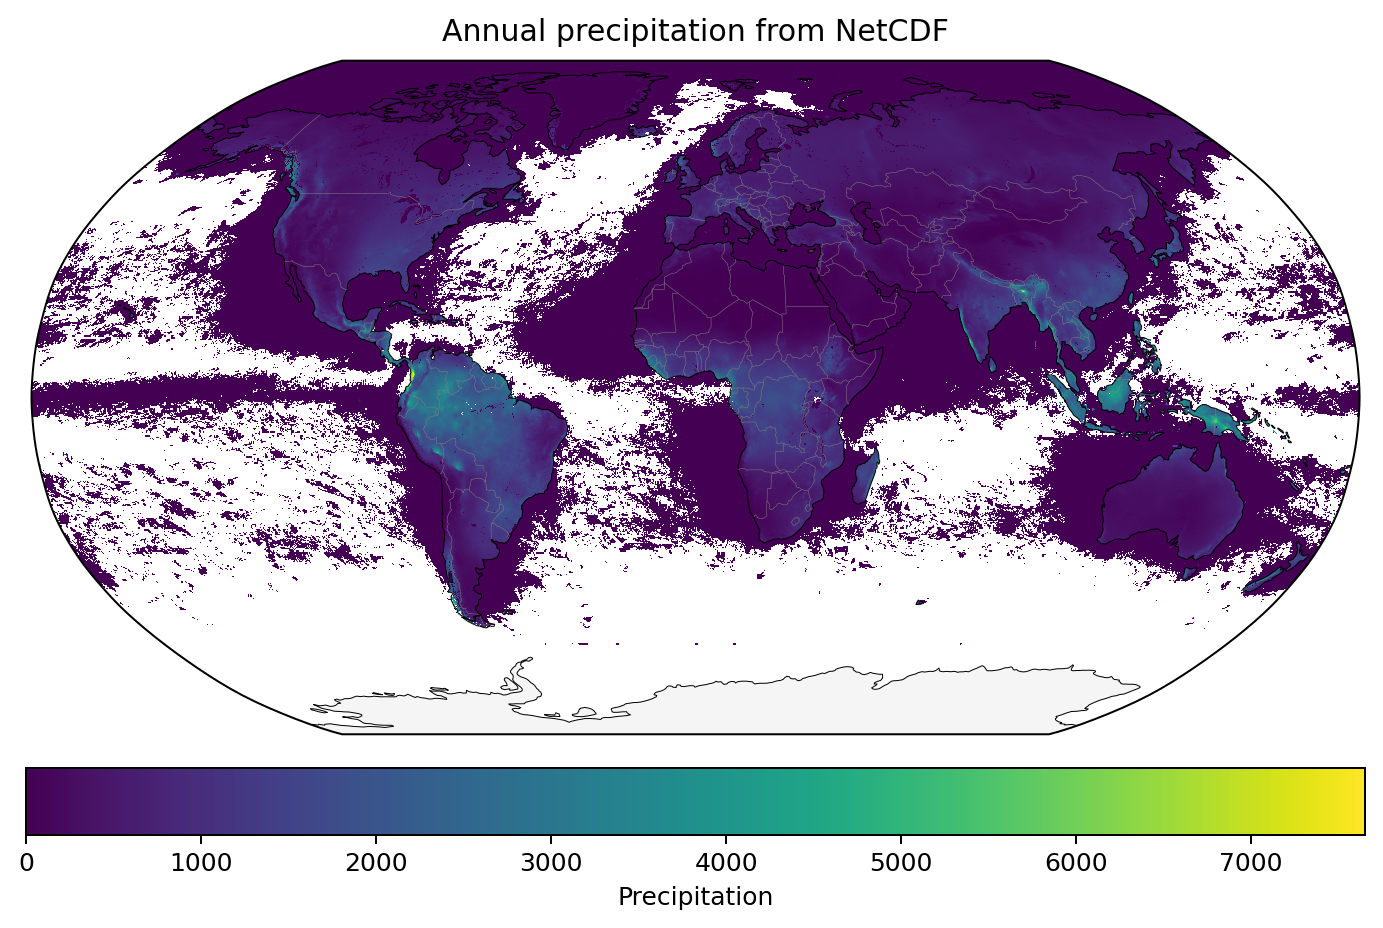

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 6), dpi=180)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=2)

mesh = ax.pcolormesh(
    lons,
    lats,
    da2d.values,
    transform=ccrs.PlateCarree(),
    shading="auto",
    zorder=1
)

cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.04, shrink=0.8)
cbar.set_label("Precipitation", fontsize=10)

ax.set_title("Annual precipitation from NetCDF", fontsize=12, pad=8)
plt.show()